# FraudGuard — 01: Keşifsel Veri Analizi (EDA)

**Kural:** Train/test split önce yapılır; tüm analizler yalnızca train seti üzerinde yürütülür.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import json
from pathlib import Path
from sklearn.model_selection import train_test_split

np.random.seed(42)

FIGURES_DIR = Path('../results/figures')
METRICS_DIR = Path('../results/metrics')
PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
with open('../config/model_params.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

SPLIT_CFG = cfg['split']
print('Split config:', SPLIT_CFG)

Split config: {'test_size': 0.2, 'random_state': 42, 'stratify': True}


## 1. Veriyi Yükle

In [3]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [4]:
print('Eksik değer sayısı:')
print(df.isnull().sum().sum())
print('\nVeri tipleri:')
print(df.dtypes.value_counts())

Eksik değer sayısı:
0

Veri tipleri:
float64    30
int64       1
Name: count, dtype: int64


## 2. Train / Test Split (EDA'dan Önce)

Test seti buradan sonra açılmaz.

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=SPLIT_CFG['test_size'],
    random_state=SPLIT_CFG['random_state'],
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train fraud rate: {y_train.mean():.4%}')

# Save splits — test set is sealed from this point on
X_train.to_csv(PROCESSED_DIR / 'X_train.csv', index=False)
X_test.to_csv(PROCESSED_DIR / 'X_test.csv', index=False)
y_train.to_csv(PROCESSED_DIR / 'y_train.csv', index=False)
y_test.to_csv(PROCESSED_DIR / 'y_test.csv', index=False)
print('Splits saved to data/processed/')

Train: 227,845 rows  |  Test: 56,962 rows
Train fraud rate: 0.1729%


Splits saved to data/processed/


## 3. Sınıf Dağılımı (Train Seti)

Normal işlem   : 227,451
Dolandırıcılık : 394
Dolandırıcılık oranı: 0.1729%


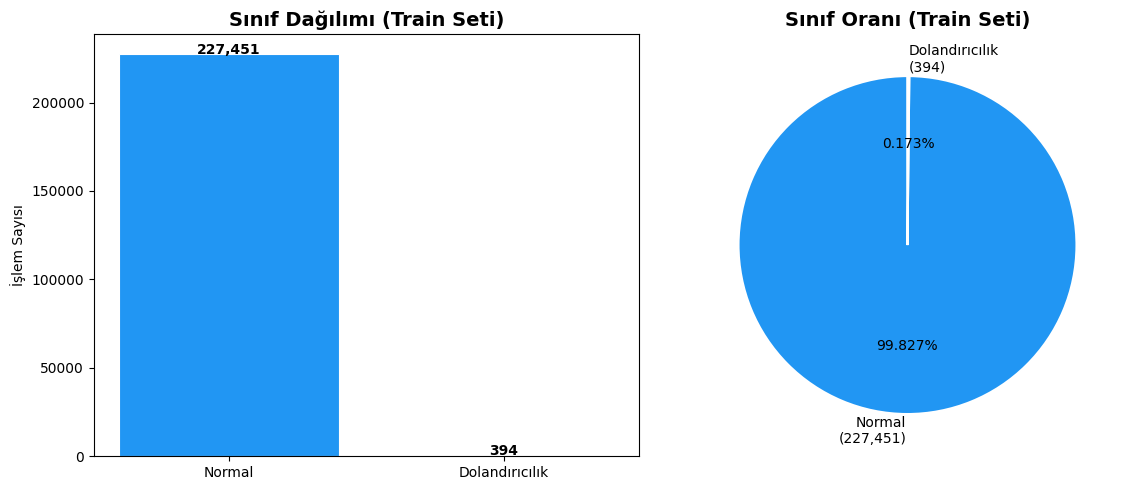

Saved: 01_class_distribution.png


In [6]:
class_counts = y_train.value_counts().sort_index()
class_labels = ['Normal', 'Dolandırıcılık']
fraud_rate = y_train.mean()

print(f'Normal işlem   : {class_counts[0]:,}')
print(f'Dolandırıcılık : {class_counts[1]:,}')
print(f'Dolandırıcılık oranı: {fraud_rate:.4%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2196F3', '#F44336']
axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sınıf Dağılımı (Train Seti)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('İşlem Sayısı')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=[f'{l}\n({c:,})' for l, c in zip(class_labels, class_counts.values)],
    autopct='%1.3f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sınıf Oranı (Train Seti)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_class_distribution.png')

## 4. İşlem Tutarı Dağılımı (Amount)

C:\Users\Kutay\AppData\Local\Temp\ipykernel_13712\1060805575.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


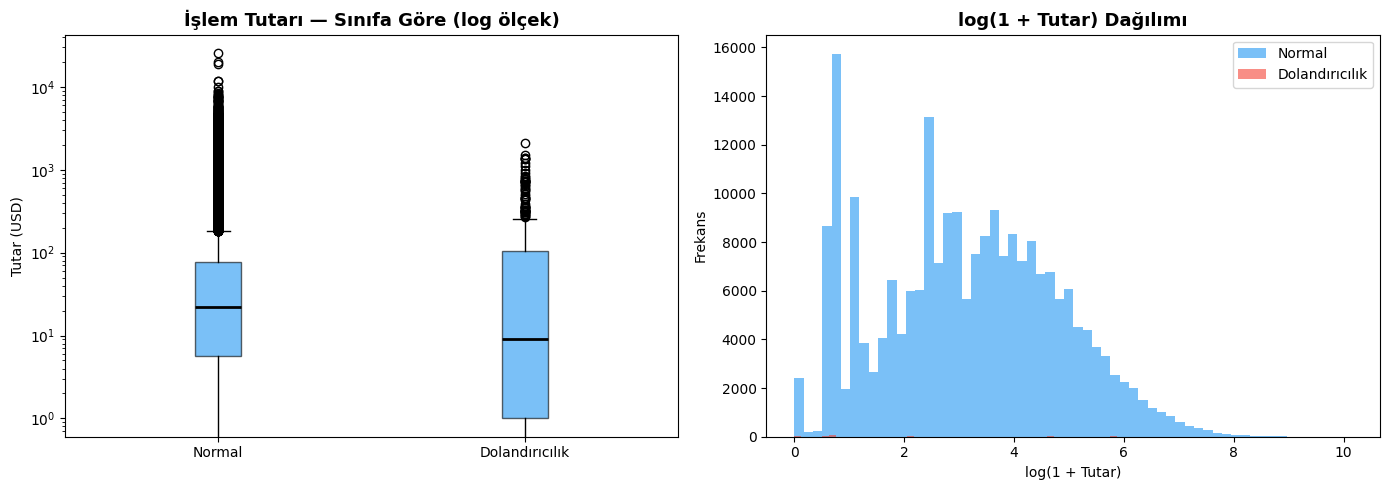

Saved: 02_amount_by_class.png

Normal  — medyan tutar: $22.00
Fraud   — medyan tutar: $9.17


In [7]:
train_df = X_train.copy()
train_df['Class'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
normal_amounts = train_df.loc[train_df['Class'] == 0, 'Amount']
fraud_amounts  = train_df.loc[train_df['Class'] == 1, 'Amount']

axes[0].boxplot(
    [normal_amounts, fraud_amounts],
    labels=['Normal', 'Dolandırıcılık'],
    patch_artist=True,
    boxprops=dict(facecolor='#2196F3', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[0].set_yscale('log')
axes[0].set_title('İşlem Tutarı — Sınıfa Göre (log ölçek)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tutar (USD)')

# Histogram overlay
axes[1].hist(np.log1p(normal_amounts), bins=60, alpha=0.6, label='Normal', color='#2196F3')
axes[1].hist(np.log1p(fraud_amounts),  bins=60, alpha=0.6, label='Dolandırıcılık', color='#F44336')
axes[1].set_title('log(1 + Tutar) Dağılımı', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Tutar)')
axes[1].set_ylabel('Frekans')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_amount_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_amount_by_class.png')

print(f"\nNormal  — medyan tutar: ${normal_amounts.median():.2f}")
print(f"Fraud   — medyan tutar: ${fraud_amounts.median():.2f}")

## 5. Zaman Dağılımı (Time)

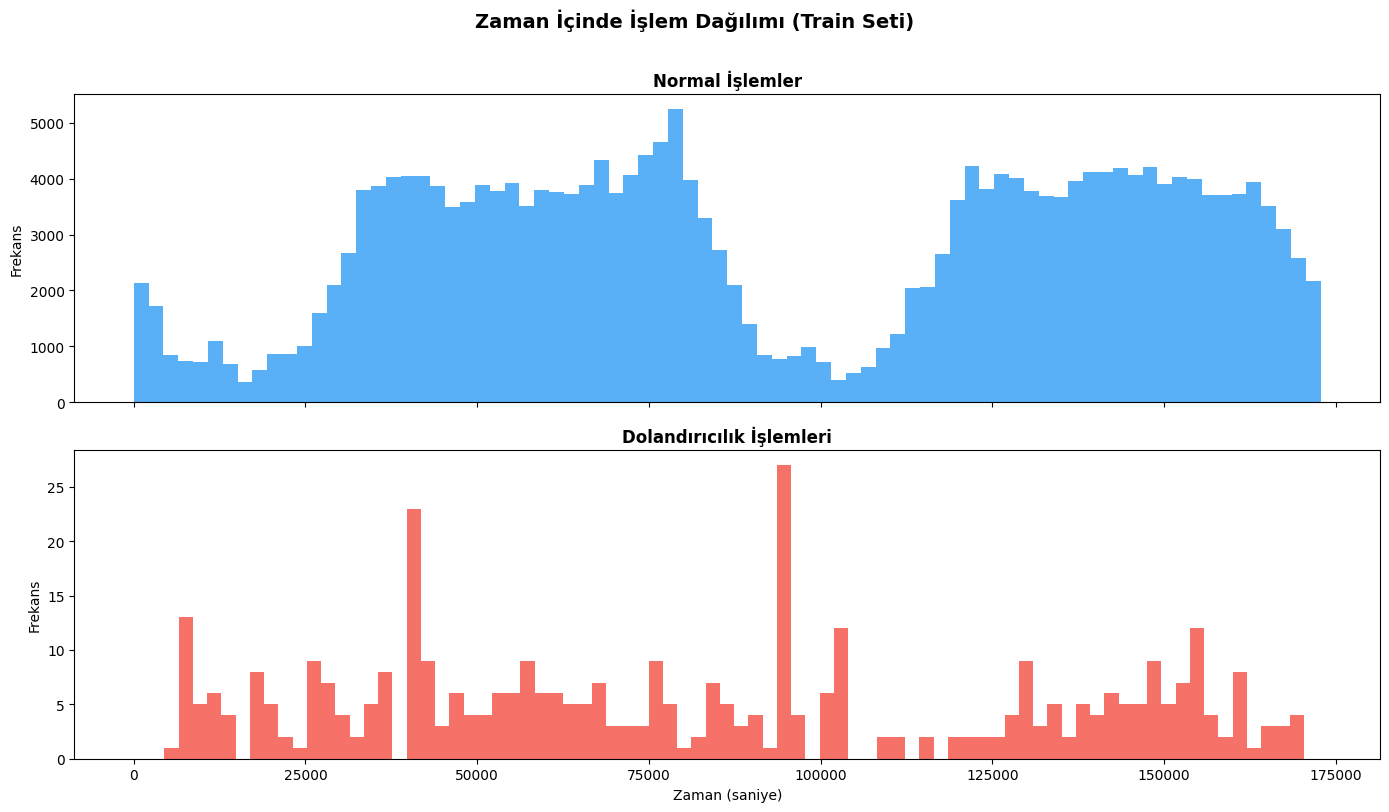

Saved: 03_time_distribution.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, cls, label, color in zip(
    axes,
    [0, 1],
    ['Normal İşlemler', 'Dolandırıcılık İşlemleri'],
    ['#2196F3', '#F44336']
):
    times = train_df.loc[train_df['Class'] == cls, 'Time']
    ax.hist(times, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frekans')

axes[1].set_xlabel('Zaman (saniye)')
fig.suptitle('Zaman İçinde İşlem Dağılımı (Train Seti)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_time_distribution.png')

## 6. Korelasyon Isı Haritası

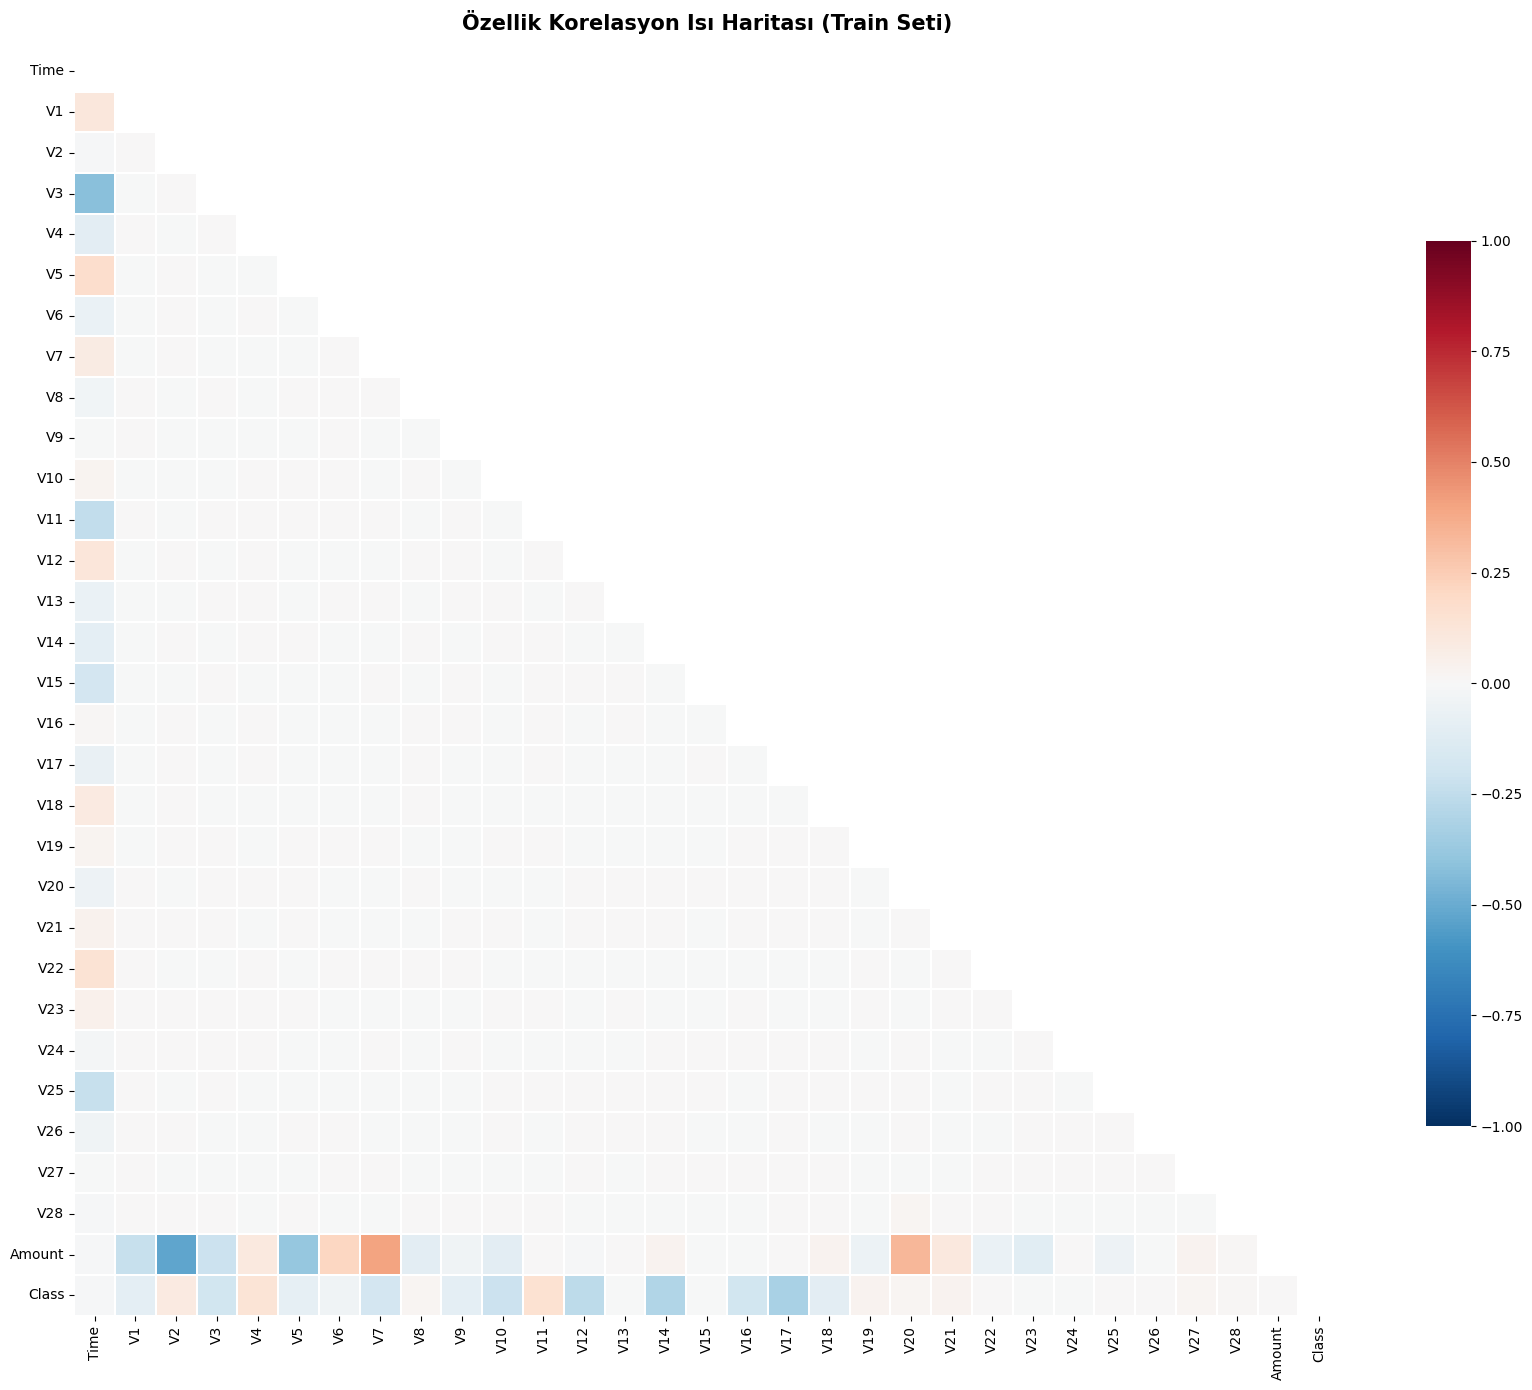

Saved: 04_correlation_heatmap.png


In [9]:
corr_matrix = train_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7},
    ax=ax
)
ax.set_title('Özellik Korelasyon Isı Haritası (Train Seti)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_correlation_heatmap.png')

## 7. En Ayırt Edici Özellikler — Feature Boxplots

Class ile en yüksek korelasyonlu 10 özellik:
V17   -0.3219
V14   -0.3011
V12   -0.2600
V10   -0.2179
V3    -0.1941
V16   -0.1938
V7    -0.1862
V11    0.1537
V4     0.1350
V18   -0.1087
Name: Class, dtype: float64


C:\Users\Kutay\AppData\Local\Temp\ipykernel_13712\4178268048.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\Kutay\AppData\Local\Temp\ipykernel_13712\4178268048.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\Kutay\AppData\Local\Temp\ipykernel_13712\4178268048.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\Kutay\AppData\Local\Temp\ipykernel_13712\4178268048.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

C:\Users\Kutay\AppData\Local\Temp\ipykernel_13712\4178268048.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(


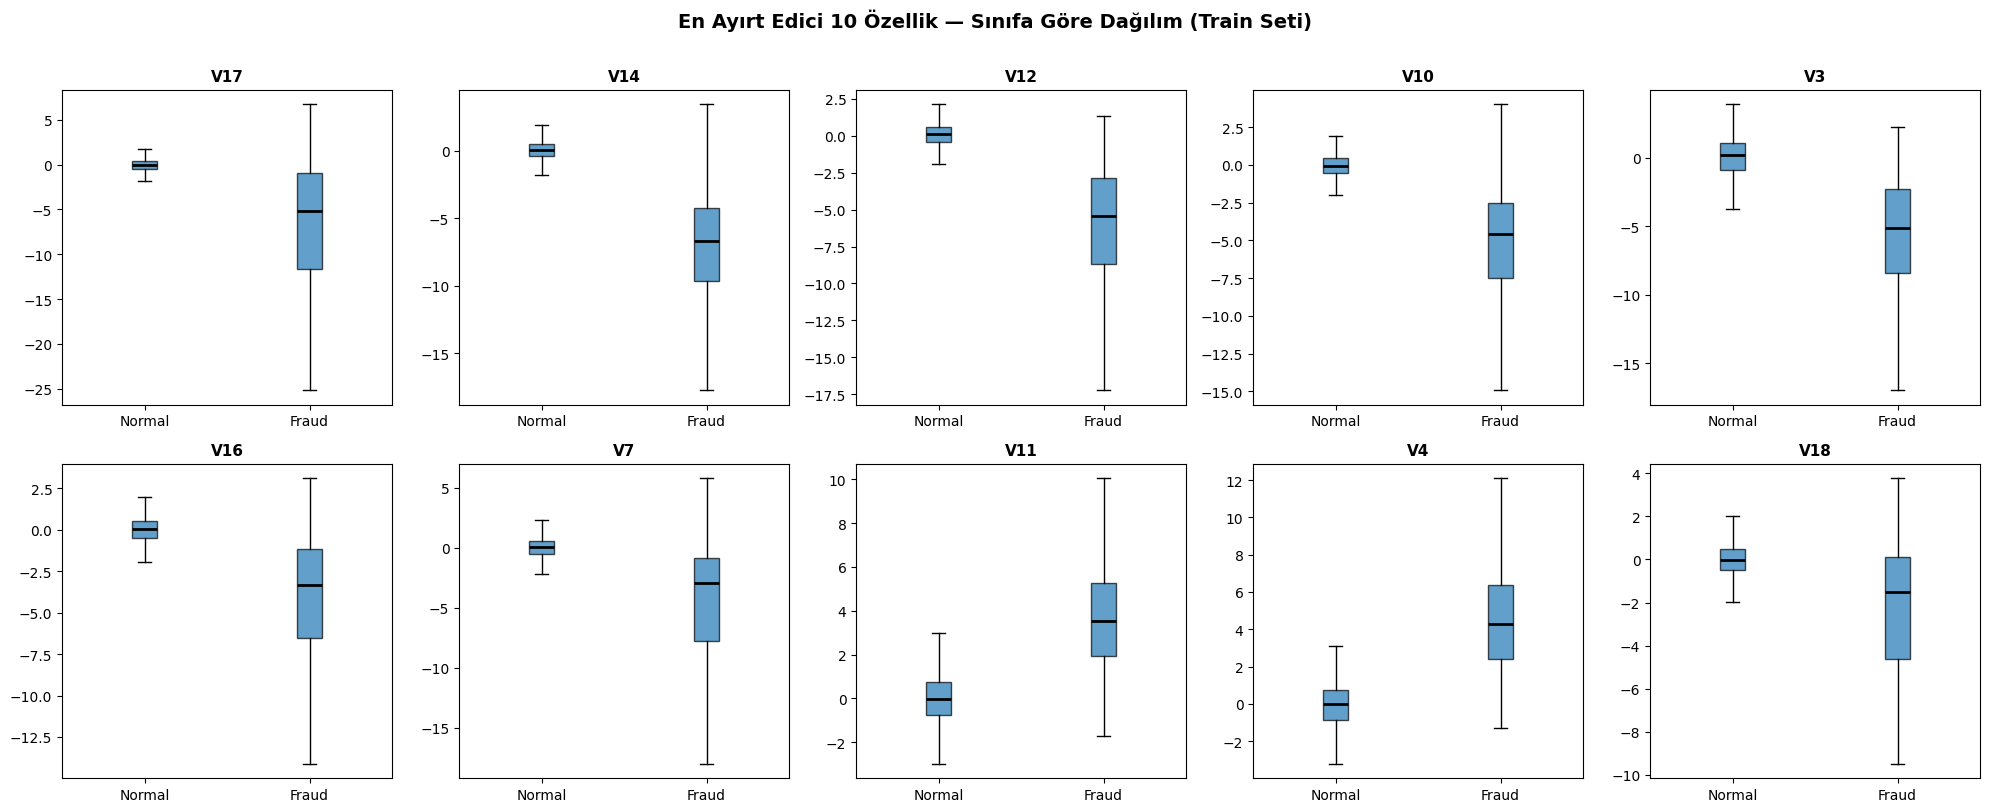

Saved: 05_feature_boxplots.png


In [10]:
# Top 10 features by absolute correlation with Class
class_corr = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
top10_features = class_corr.head(10).index.tolist()

print('Class ile en yüksek korelasyonlu 10 özellik:')
print(corr_matrix['Class'][top10_features].round(4))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(top10_features):
    normal_vals = train_df.loc[train_df['Class'] == 0, feat]
    fraud_vals  = train_df.loc[train_df['Class'] == 1, feat]
    axes[i].boxplot(
        [normal_vals, fraud_vals],
        labels=['Normal', 'Fraud'],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        showfliers=False
    )
    axes[i].set_title(feat, fontsize=11, fontweight='bold')

fig.suptitle('En Ayırt Edici 10 Özellik — Sınıfa Göre Dağılım (Train Seti)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_feature_boxplots.png')

## 8. EDA Özet Metrikleri — JSON Kayıt

In [11]:
summary = {
    'dataset': {
        'total_rows': int(df.shape[0]),
        'total_features': int(df.shape[1] - 1),
        'missing_values': int(df.isnull().sum().sum())
    },
    'train_set': {
        'n_rows': int(X_train.shape[0]),
        'n_normal': int(class_counts[0]),
        'n_fraud': int(class_counts[1]),
        'fraud_rate': round(float(fraud_rate), 6)
    },
    'test_set': {
        'n_rows': int(X_test.shape[0])
    },
    'amount_stats': {
        'normal_median': round(float(normal_amounts.median()), 2),
        'fraud_median': round(float(fraud_amounts.median()), 2),
        'normal_max': round(float(normal_amounts.max()), 2),
        'fraud_max': round(float(fraud_amounts.max()), 2)
    },
    'top10_features_by_class_correlation': {
        feat: round(float(corr_matrix['Class'][feat]), 4)
        for feat in top10_features
    }
}

with open(METRICS_DIR / '01_eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print('\nSaved: 01_eda_summary.json')

{
  "dataset": {
    "total_rows": 284807,
    "total_features": 30,
    "missing_values": 0
  },
  "train_set": {
    "n_rows": 227845,
    "n_normal": 227451,
    "n_fraud": 394,
    "fraud_rate": 0.001729
  },
  "test_set": {
    "n_rows": 56962
  },
  "amount_stats": {
    "normal_median": 22.0,
    "fraud_median": 9.17,
    "normal_max": 25691.16,
    "fraud_max": 2125.87
  },
  "top10_features_by_class_correlation": {
    "V17": -0.3219,
    "V14": -0.3011,
    "V12": -0.26,
    "V10": -0.2179,
    "V3": -0.1941,
    "V16": -0.1938,
    "V7": -0.1862,
    "V11": 0.1537,
    "V4": 0.135,
    "V18": -0.1087
  }
}

Saved: 01_eda_summary.json
